# Qiskit Fall Fest 2026 — Challenge 3: Can You Change the Correlation?
**IBM Quantum | Vishnu Institute of Technology**

## Objective
Build the original Bell-state circuit, add exactly one quantum gate, measure both qubits for 100 shots, and compare the measurement histograms.

**Design constraints met:** exactly 2 qubits, both qubits measured, starts from the Bell-state circuit, only one gate added, 3 gates before measurement (limit is 4), Qiskit only, 100 shots.

## 1. Setup
Install the required packages if they are not already installed.

In [1]:
%pip install -q qiskit qiskit-aer matplotlib pylatexenc

In [2]:
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

SHOTS = 100
simulator = AerSimulator()


def run_circuit(qc, shots=SHOTS):
    """Run a circuit on the simulator and return the measurement counts."""
    compiled = transpile(qc, simulator)
    return simulator.run(compiled, shots=shots).result().get_counts()


def summarize(label, counts):
    """Print the four possible outcomes and how often the two bits matched."""
    total = sum(counts.values())
    same = counts.get('00', 0) + counts.get('11', 0)
    diff = counts.get('01', 0) + counts.get('10', 0)
    print(f'{label}: 00={counts.get("00", 0)}, 01={counts.get("01", 0)}, '
          f'10={counts.get("10", 0)}, 11={counts.get("11", 0)}  |  '
          f'same bits: {same} ({same/total:.0%}), different bits: {diff} ({diff/total:.0%})')


print(f'Setup complete: {SHOTS} shots per circuit.')

Setup complete: 100 shots per circuit.


## 2. Original Bell-state circuit — prediction before execution

The Bell-state circuit applies an H gate to qubit 0, then a CNOT with qubit 0 as control and qubit 1 as target.

**Prediction:**
- Measuring both qubits gives correlated outcomes: the two bits always match.
- `00` and `11` should each appear about 50% of the time (roughly 50 counts each in 100 shots, not exactly).
- `01` and `10` should not appear at all on an ideal simulator.

The circuit has 2 gates before measurement.

Original Bell-state circuit:


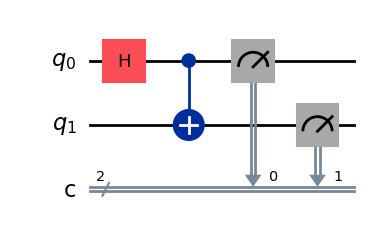

In [3]:
original = QuantumCircuit(2, 2)
original.h(0)
original.cx(0, 1)
original.measure([0, 1], [0, 1])

print('Original Bell-state circuit:')
display(original.draw('mpl'))

Original circuit counts: {'11': 41, '00': 59}


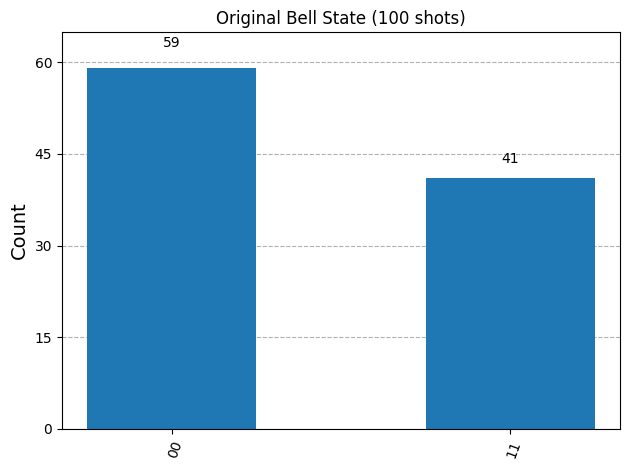

In [4]:
original_counts = run_circuit(original)
print('Original circuit counts:', original_counts)
display(plot_histogram(original_counts, title='Original Bell State (100 shots)'))

## 3. Modified circuit — add one X gate

**Modification:** add one X gate on qubit 1, after the CNOT and before the measurement. Nothing else is changed. The modified circuit has 3 gates before measurement.

**Prediction before execution:**
- *Which outcomes do I expect?* `01` and `10`, each about 50%.
- *Will the two qubits still produce the same outcomes?* No. The X gate flips qubit 1, so the two bits will now always be opposite.
- *Will `00` and `11` dominate?* No. They should disappear almost completely (zero on an ideal simulator).
- *Could `01` and `10` become more frequent?* Yes, they replace `00` and `11` as the only outcomes.

*Reading the labels:* Qiskit prints the bits with qubit 1 on the left and qubit 0 on the right. Either way, `01` and `10` are the two outcomes where the bits differ.

Modified Bell-state circuit:


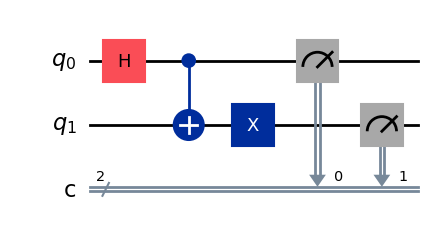

In [5]:
modified = QuantumCircuit(2, 2)
modified.h(0)
modified.cx(0, 1)
modified.x(1)  # The one added gate: flip qubit 1
modified.measure([0, 1], [0, 1])

print('Modified Bell-state circuit:')
display(modified.draw('mpl'))

Modified circuit counts: {'01': 45, '10': 55}


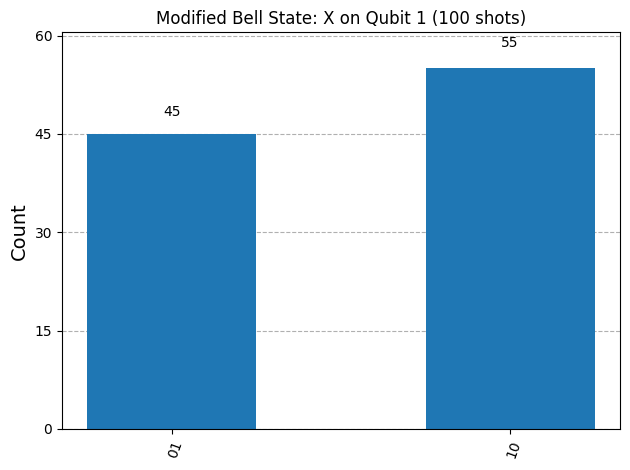

In [6]:
modified_counts = run_circuit(modified)
print('Modified circuit counts:', modified_counts)
display(plot_histogram(modified_counts, title='Modified Bell State: X on Qubit 1 (100 shots)'))

## 4. Compare both circuits

First a table of the observed counts, then both histograms on one chart.

Circuit                      00     01     10     11
----------------------------------------------------
Original Bell state          59      0      0     41
Modified (X on qubit 1)       0     45     55      0

Original: 00=59, 01=0, 10=0, 11=41  |  same bits: 100 (100%), different bits: 0 (0%)
Modified: 00=0, 01=45, 10=55, 11=0  |  same bits: 0 (0%), different bits: 100 (100%)


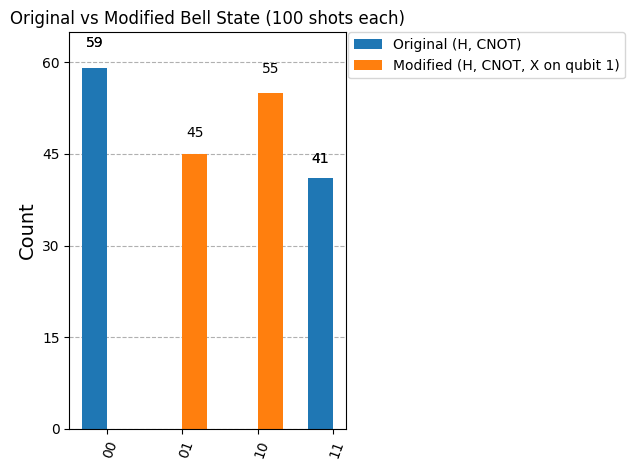

In [7]:
print(f'{"Circuit":<24} {"00":>6} {"01":>6} {"10":>6} {"11":>6}')
print('-' * 52)
for label, counts in [('Original Bell state', original_counts), ('Modified (X on qubit 1)', modified_counts)]:
    print(f'{label:<24} {counts.get("00", 0):>6} {counts.get("01", 0):>6} '
          f'{counts.get("10", 0):>6} {counts.get("11", 0):>6}')

print()
summarize('Original', original_counts)
summarize('Modified', modified_counts)

display(plot_histogram(
    [original_counts, modified_counts],
    legend=['Original (H, CNOT)', 'Modified (H, CNOT, X on qubit 1)'],
    title='Original vs Modified Bell State (100 shots each)'
))

## 5. Predictions vs observed results
The cell below checks each prediction against the counts from this run.

In [8]:
orig_match = original_counts.get('00', 0) + original_counts.get('11', 0)
mod_diff = modified_counts.get('01', 0) + modified_counts.get('10', 0)

print(f'Original: {orig_match}/{SHOTS} shots had matching bits (predicted: all {SHOTS}).')
print(f'Original: 00 = {original_counts.get("00", 0)}, 11 = {original_counts.get("11", 0)} (predicted: about 50 each).')
print(f'Modified: {mod_diff}/{SHOTS} shots had opposite bits (predicted: all {SHOTS}).')
print(f'Modified: 01 = {modified_counts.get("01", 0)}, 10 = {modified_counts.get("10", 0)} (predicted: about 50 each).')
print('All predictions confirmed:', orig_match == SHOTS and mod_diff == SHOTS)

Original: 100/100 shots had matching bits (predicted: all 100).
Original: 00 = 59, 11 = 41 (predicted: about 50 each).
Modified: 100/100 shots had opposite bits (predicted: all 100).
Modified: 01 = 45, 10 = 55 (predicted: about 50 each).
All predictions confirmed: True


## 6. Explanation of the change

- In the original circuit, the **H gate** puts qubit 0 into an equal superposition. The **CNOT** then links qubit 1 to qubit 0, creating the Bell state (|00⟩ + |11⟩)/√2. Each measurement is random, but the two qubits always agree, so only `00` and `11` appear, each about half the time.
- The added **X gate** on qubit 1 flips that qubit's value just before measurement. The state becomes (|01⟩ + |10⟩)/√2, so whenever qubit 0 gives 0, qubit 1 gives 1, and the other way round.
- The qubits are still perfectly correlated, but the relationship has changed from *same* to *opposite*. Each individual outcome is still a 50/50 coin flip, and the 100-shot counts can differ slightly from an exact 50/50 split.

## 7. Conclusion

A single added X gate changes the measurement correlation of the Bell state from matching outcomes (`00` and `11`) to opposite outcomes (`01` and `10`). Both circuits use exactly two qubits, measure both qubits, use no more than four gates before measurement, and run for 100 shots.